# Day-Ahead Electricity Price Forecasting

**Goal:** forecast hourly day-ahead electricity prices for the Germany-Luxembourg (DE-LU) bidding zone using historical market information.



In [1]:
from pathlib import Path
import json
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "README.md").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if not (PROJECT_ROOT / "README.md").exists():
    PROJECT_ROOT = Path.cwd()

RAW = PROJECT_ROOT / "data" / "raw"
PROCESSED = PROJECT_ROOT / "data" / "processed"
CHARTS = PROJECT_ROOT / "outputs" / "charts"

for p in [RAW, PROCESSED, CHARTS]:
    p.mkdir(parents=True, exist_ok=True)

DATA_URL = "https://raw.githubusercontent.com/juaAI/ENTSOE-Hackathon/main/entsoe_data_2023.csv"
DATA_FILE = RAW / "entsoe_data_2023.csv"

print("Project root:", PROJECT_ROOT)


Project root: C:\Users\karedi Deepak\Downloads\Day_Ahead_Electricity_Price_Forecasting_COMPLETE\Day_Ahead_Electricity_Price_Forecasting


## 1. Load the public ENTSO-E dataset

The source dataset contains the DE-LU day-ahead electricity price plus load and generation variables.

If the CSV is already present in `data/raw`, it is reused. Otherwise the notebook downloads it automatically.


In [2]:
if not DATA_FILE.exists():
    print("Downloading public ENTSO-E dataset...")
    urllib.request.urlretrieve(DATA_URL, DATA_FILE)
    print("Download complete.")

df_raw = pd.read_csv(DATA_FILE, index_col=0, parse_dates=True)
df_raw = df_raw.sort_index()

print("Rows:", len(df_raw))
print("Columns:", len(df_raw.columns))
print(df_raw.head(3))


Download complete.
Rows: 34944
Columns: 31
                     load_actual_mw  price_eur_mwh  \
2023-01-01 00:00:00         38119.0          -1.07   
2023-01-01 00:15:00         38014.0            NaN   
2023-01-01 00:30:00         38419.0            NaN   

                     gen_actual_biomass_actual_aggregated_mw  \
2023-01-01 00:00:00                                   4021.0   
2023-01-01 00:15:00                                   4030.0   
2023-01-01 00:30:00                                   4024.0   

                     gen_actual_fossil_brown_coal_lignite_actual_aggregated_mw  \
2023-01-01 00:00:00                                             3876.0           
2023-01-01 00:15:00                                             3863.0           
2023-01-01 00:30:00                                             3870.0           

                     gen_actual_fossil_coal_derived_gas_actual_aggregated_mw  \
2023-01-01 00:00:00                                              635.0    

## 2. Select the market variables

We use:
- day-ahead price as the target
- actual load
- onshore wind generation
- offshore wind generation
- solar generation

Only **lagged** market variables are used later as predictors.


In [3]:
required = {
    "price_eur_mwh": "price",
    "load_actual_mw": "load",
    "gen_actual_wind_onshore_actual_aggregated_mw": "wind_onshore",
    "gen_actual_wind_offshore_actual_aggregated_mw": "wind_offshore",
    "gen_actual_solar_actual_aggregated_mw": "solar",
}

missing = [c for c in required if c not in df_raw.columns]
if missing:
    raise KeyError(f"Required columns are missing: {missing}")

df = df_raw[list(required)].rename(columns=required).copy()

for c in df.columns:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna(subset=["price"]).sort_index()
df = df[~df.index.duplicated(keep="first")]

print("Clean rows:", len(df))
print(df[["price", "load", "wind_onshore", "wind_offshore", "solar"]].describe().round(2))


Clean rows: 8736
         price      load  wind_onshore  wind_offshore     solar
count  8736.00   8736.00       8736.00        8736.00   8736.00
mean     95.41  52925.84      13593.65        2676.37   6383.38
std      47.43   9209.24      10551.37        1824.48   9919.24
min    -500.00  28407.00        121.00           0.00      1.00
25%      76.08  45365.00       4979.75        1029.75      3.00
50%      98.09  52955.50      10631.50        2437.50     99.00
75%     122.21  60120.50      20083.50        4154.25   9848.50
max     524.27  74305.00      48725.00        7635.00  41611.00


## 3. Basic price behaviour

First look at the historical price series. Electricity prices can show strong daily, weekly and seasonal patterns and occasional spikes.


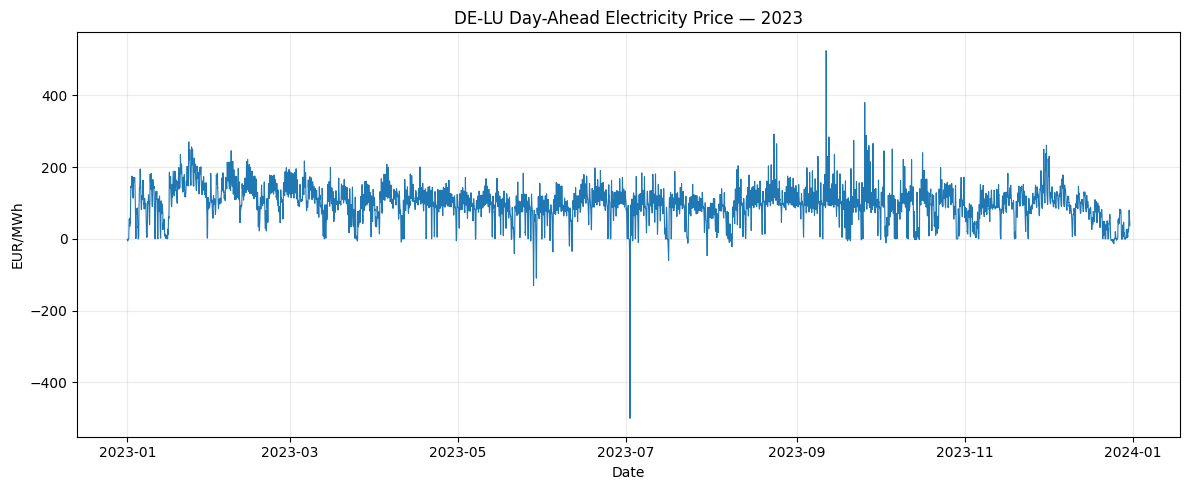

In [4]:
fig, ax = plt.subplots()
ax.plot(df.index, df["price"], linewidth=0.8)
ax.set_title("DE-LU Day-Ahead Electricity Price — 2023")
ax.set_ylabel("EUR/MWh")
ax.set_xlabel("Date")
fig.tight_layout()
fig.savefig(CHARTS / "01_price_history.png", dpi=180, bbox_inches="tight")
plt.show()


## 4. Feature engineering

For a day-ahead forecast at hour `t`, we should not use actual information from hour `t`.

The main features are:
- price lags: 24h, 48h, 168h
- load lags: 24h, 168h
- wind lags: 24h, 168h
- solar lags: 24h, 168h
- rolling price mean/std using only past observations
- hour, day of week and month

The 168-hour lag represents the same hour one week earlier.


In [5]:
features = df.copy()

# Calendar features
features["hour"] = features.index.hour
features["day_of_week"] = features.index.dayofweek
features["month"] = features.index.month

# Historical lags
for lag in [24, 48, 168]:
    features[f"price_lag_{lag}"] = features["price"].shift(lag)

for col in ["load", "wind_onshore", "wind_offshore", "solar"]:
    for lag in [24, 168]:
        features[f"{col}_lag_{lag}"] = features[col].shift(lag)

# Past-only rolling statistics
features["price_roll_24_mean"] = features["price"].shift(1).rolling(24).mean()
features["price_roll_24_std"] = features["price"].shift(1).rolling(24).std()
features["price_roll_168_mean"] = features["price"].shift(1).rolling(168).mean()

feature_cols = [
    "hour", "day_of_week", "month",
    "price_lag_24", "price_lag_48", "price_lag_168",
    "load_lag_24", "load_lag_168",
    "wind_onshore_lag_24", "wind_onshore_lag_168",
    "wind_offshore_lag_24", "wind_offshore_lag_168",
    "solar_lag_24", "solar_lag_168",
    "price_roll_24_mean", "price_roll_24_std", "price_roll_168_mean",
]

model_df = features.dropna(subset=feature_cols + ["price"]).copy()

print("Model rows:", len(model_df))
print("Features:", len(feature_cols))
print(feature_cols)


Model rows: 8568
Features: 17
['hour', 'day_of_week', 'month', 'price_lag_24', 'price_lag_48', 'price_lag_168', 'load_lag_24', 'load_lag_168', 'wind_onshore_lag_24', 'wind_onshore_lag_168', 'wind_offshore_lag_24', 'wind_offshore_lag_168', 'solar_lag_24', 'solar_lag_168', 'price_roll_24_mean', 'price_roll_24_std', 'price_roll_168_mean']


## 5. Chronological train/test split

Random train-test splitting is avoided because it can leak future market conditions into the training set.

The final month of 2023 is held out as the test period.


In [6]:
test_start = pd.Timestamp("2023-12-01")

train = model_df[model_df.index < test_start].copy()
test = model_df[model_df.index >= test_start].copy()

X_train = train[feature_cols]
y_train = train["price"]

X_test = test[feature_cols]
y_test = test["price"]

print("Train:", train.index.min(), "to", train.index.max(), "|", len(train), "rows")
print("Test :", test.index.min(), "to", test.index.max(), "|", len(test), "rows")


Train: 2023-01-08 00:00:00 to 2023-11-30 23:00:00 | 7848 rows
Test : 2023-12-01 00:00:00 to 2023-12-30 23:00:00 | 720 rows


## 6. Train the model

A gradient-boosting regressor is used because it can capture nonlinear relationships while remaining much easier to explain than a deep neural network.

The model is trained only on the earlier observations.


In [7]:
model = GradientBoostingRegressor(
    n_estimators=250,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)
pred = model.predict(X_test)

test_results = test[["price"]].copy()
test_results["predicted_price"] = pred
test_results["error"] = test_results["price"] - test_results["predicted_price"]


## 7. Evaluate forecast accuracy

- **MAE**: average absolute forecast error in EUR/MWh.
- **RMSE**: penalizes larger errors more heavily.

Lower values indicate smaller forecast errors.


In [8]:
mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))

metrics = {
    "test_start": str(test.index.min()),
    "test_end": str(test.index.max()),
    "train_rows": int(len(train)),
    "test_rows": int(len(test)),
    "MAE_EUR_per_MWh": float(mae),
    "RMSE_EUR_per_MWh": float(rmse),
}

print(f"MAE : {mae:.2f} EUR/MWh")
print(f"RMSE: {rmse:.2f} EUR/MWh")


MAE : 17.17 EUR/MWh
RMSE: 23.18 EUR/MWh


## 8. Actual vs predicted prices


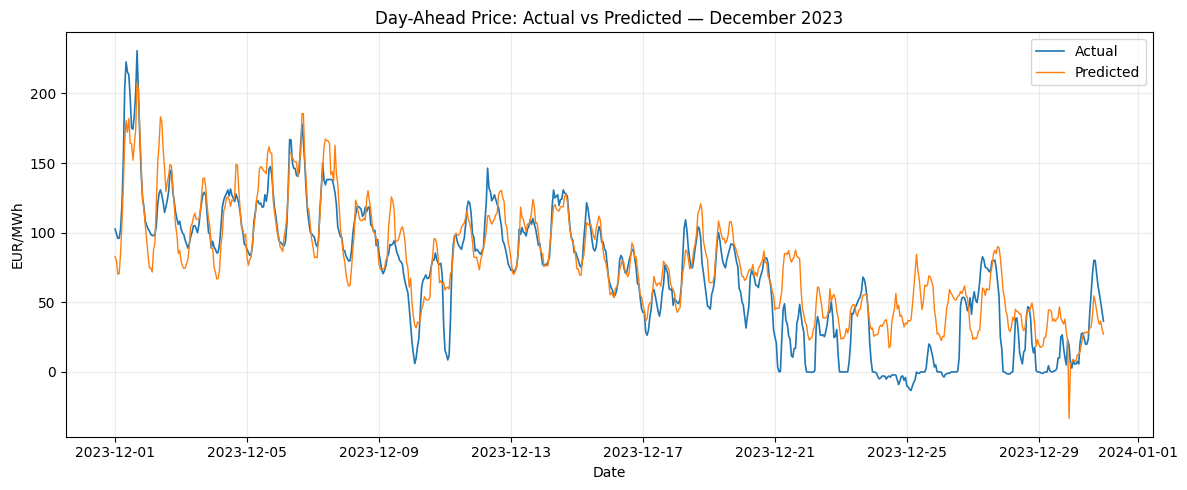

In [9]:
fig, ax = plt.subplots()
ax.plot(test_results.index, test_results["price"], label="Actual", linewidth=1.2)
ax.plot(test_results.index, test_results["predicted_price"], label="Predicted", linewidth=1.0)
ax.set_title("Day-Ahead Price: Actual vs Predicted — December 2023")
ax.set_ylabel("EUR/MWh")
ax.set_xlabel("Date")
ax.legend()
fig.tight_layout()
fig.savefig(CHARTS / "02_actual_vs_predicted.png", dpi=180, bbox_inches="tight")
plt.show()


## 9. Feature importance

Feature importance shows which variables contributed most to the fitted model.

This is an interpretation tool, not proof that a feature causes price movements.


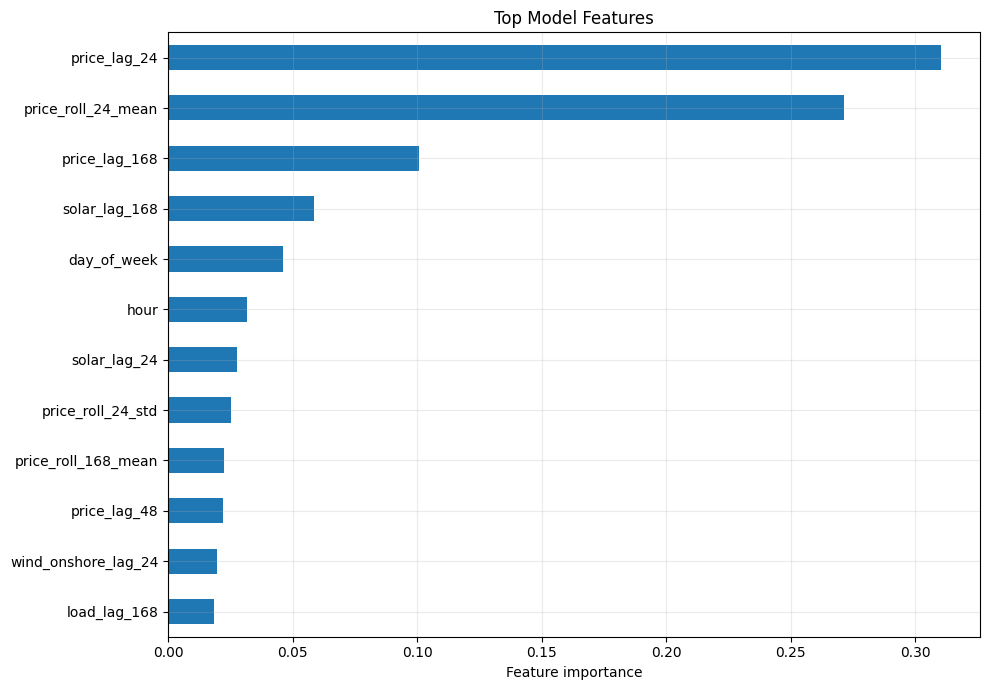

price_lag_24           0.3105
price_roll_24_mean     0.2712
price_lag_168          0.1008
solar_lag_168          0.0588
day_of_week            0.0459
hour                   0.0319
solar_lag_24           0.0277
price_roll_24_std      0.0254
price_roll_168_mean    0.0226
price_lag_48           0.0222
dtype: float64


In [10]:
importance = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
importance.tail(12).plot(kind="barh", ax=ax)
ax.set_title("Top Model Features")
ax.set_xlabel("Feature importance")
fig.tight_layout()
fig.savefig(CHARTS / "03_feature_importance.png", dpi=180, bbox_inches="tight")
plt.show()

print(importance.sort_values(ascending=False).head(10).round(4))


## 10. Forecast error distribution


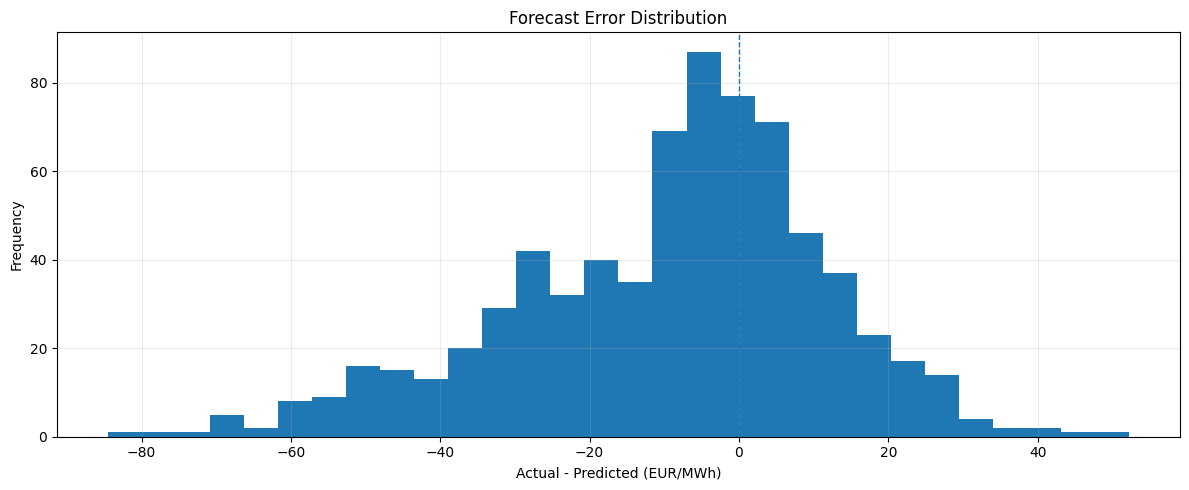

In [11]:
fig, ax = plt.subplots()
ax.hist(test_results["error"], bins=30)
ax.axvline(0, linestyle="--", linewidth=1)
ax.set_title("Forecast Error Distribution")
ax.set_xlabel("Actual - Predicted (EUR/MWh)")
ax.set_ylabel("Frequency")
fig.tight_layout()
fig.savefig(CHARTS / "04_test_error_distribution.png", dpi=180, bbox_inches="tight")
plt.show()
